In [1]:
%load_ext autoreload
%autoreload 2

import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import LineString, box, MultiLineString
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage.graph import route_through_array
from skimage.draw import line as skline
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, LogNorm

import utils 

# all figs can be zoomed into: comment out for stationary figs
%matplotlib widget 

All functions called this Notebook are stored in the utils.py file

### Rupture map
1. Load rupture map shapefile from Sinan's work
2. Plot rupture map shapefile

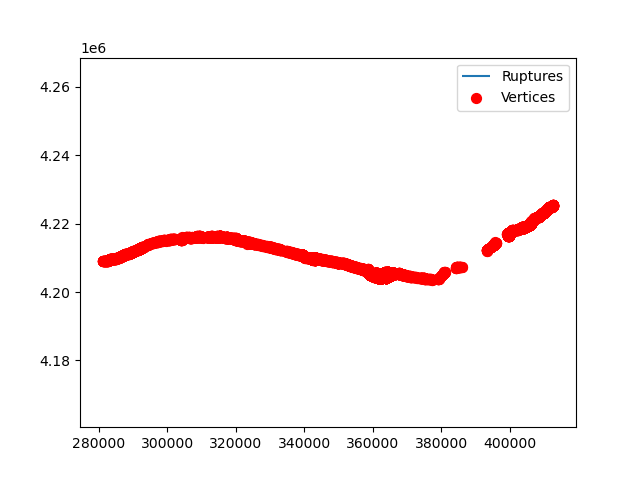

In [2]:
rupture_map = gpd.read_file('Akciz_Map_Files/Cardak&Ciglik_HGM_v12.shp')
rupture_map = rupture_map.to_crs(epsg=32637) # convert to utm coords, zone 37 N

fig, ax = plt.subplots()
rupture_map.plot(ax=ax,label='Ruptures')
vertices = rupture_map.get_coordinates()
plt.scatter(vertices.x, vertices.y,s=50,c='red',zorder=5,label='Vertices')
plt.axis('equal')
plt.legend()

### Resample each rupture strand to evenly spaced vertices

To avoid issues in the roughness calculation later, resample all ruptures in the map at the same evenly spaced interval

In [3]:
rupture_map = rupture_map[rupture_map.geometry.notna() & ~rupture_map.geometry.is_empty].copy()
resample_step = 5.0 # meters --- note shorter fractures maintain their original and final vertex
rupture_map["geometry"] = rupture_map.geometry.apply(lambda g: utils.resample_geometry(g, resample_step))

# fig, ax = plt.subplots()
# rupture_map.plot(ax=ax,label='Ruptures')
# vertices = rupture_map.get_coordinates()
# plt.scatter(vertices.x, vertices.y,s=50,c='red',zorder=5,label='Vertices')
# plt.axis('equal')
# plt.legend()

### Construct reference line for the rupture trace
Following approach of Thomas et al. (2023), least cost analysis for establishing primary rupture trace based on a fracture map

Thomas, K., Milliner, C., Chen, R., Chiou, B., Dawson, T., & Petersen, M. (2025). Least cost path analysis as an objective and automatic method to define the main fault trace for probabilistic fault displacement hazard analyses. Earthquake Spectra, 41(4), 2938-2967.

Notes: 
- Note that Thomas et al. (2025) conducts part of the analysis in Python, then further processes the LCP line in GIS and manually. Here the GIS steps are included in the Python workflow.
- We use a resolution of 1.5 m, smoothing over 3 m. This is a good compromise for following the rupture trace well without generation of the lcp line taking too long.

In [4]:
# define start and end points for line, east and west-most points works well for this event
vertices = rupture_map.get_coordinates()
w = vertices.iloc[vertices.x.values.argmin()]   # single westmost vertex
e = vertices.iloc[vertices.x.values.argmax()]   # single eastmost vertex

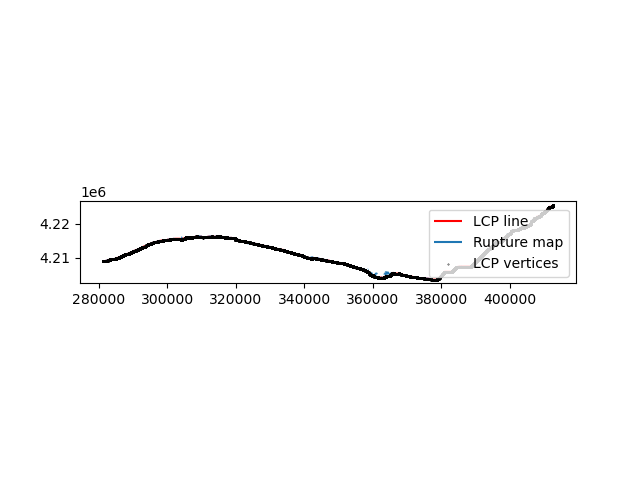

In [5]:
res = 1.5 # meters
smooth_tol = 3.0 # meters
lcp, path_xy = utils.generate_lcp("Akciz_Map_Files/Cardak&Ciglik_HGM_v12.shp", 32637, w, e, res=res, smooth_tol=smooth_tol)

fig, ax = plt.subplots()
lcp.plot(color='red',ax=ax,label='LCP line')
lcp_vertices = lcp.get_coordinates()
rupture_map.plot(ax=ax, label='Rupture map')
plt.scatter(lcp_vertices.x, lcp_vertices.y,s=0.1,c='k',zorder=5, label='LCP vertices')
plt.legend()

In [ ]:
lcp = lcp.set_crs(epsg=32637)  # save lcp line to run faster by loading it in the future 
lcp.to_file("refline_Elbistan.shp")

In [20]:
# lcp = gpd.read_file("refline_Elbistan.shp") # load lcp directly and comment out previous cell to run faster

### Move along rupture and measure roughness and number of strands per box

For each step along the reference (LCP) trace we center a square window on
the trace and measure how much the mapped rupture deviates from a straight
line inside that window.

**Roughness**

1. Step along the LCP every along_trace_step (in meters).
2. At each step, place a square window of side 2 * box_half_size
   (e.g. 1000 m) centered on the trace point.
3. Clip all rupture strands to the window and pool their vertices.
4. Fit a straight line to vertices (n=M) in window (least squares)
5. Take the perpendicular distance $p_i$ of each vertex from the fit line.
6. Roughness is the RMS perpendicular deviation, normalized by the length
   of the fit line spanning the window in the fault direction, $L_\text{ref}$:

$$
\text{roughness} = \frac{\sqrt{\dfrac{1}{M}\sum_{i=1}^{M} p_i^{\,2}}}{L_\text{ref}}
$$

Normalizing by the window-spanning length makes the metric dimensionless and
means windows with little or no mapped rupture come out smooth.

Note $L_\text{ref}$ varies with strike. 

Empty windows return NaN.

**Strand count**
1. Step along the LCP every along_trace_step (in meters).
2. At each step, place a square window of side 2 * box_half_size
   (e.g. 1000 m) centered on the trace point.
3. Clip all rupture strands to the window.
4. Count number of strands in window.

Empty windows return NaN.

In [7]:
along_half = 250 # box dim along strike, meters
across_half = 2000 # box dim across strike, meters
along_trace_step = 100 # meters
roughness_n_strands_RZW_df= utils.roughness_n_strands_along_lcp(lcp, rupture_map, along_half, across_half, along_trace_step)
roughness_n_strands_RZW_df.head()

,distance along lcp line,x_coord_midpoint,y_coord_midpoint,n_strands,roughness
0,0.0,281039.666685,4.209040e+06,1.0,0.003127
1,100.0,281138.921096,4.209030e+06,1.0,0.003254
2,200.0,281238.133735,4.209020e+06,2.0,0.004512
3,300.0,281336.775081,4.209007e+06,2.0,0.007300
4,400.0,281436.431657,4.209002e+06,2.0,0.011372


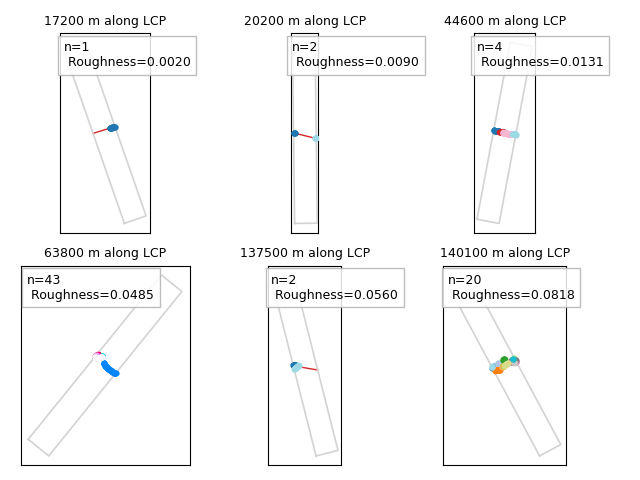

In [8]:
# plot some boxes to visualize the roughness estimate approach and strand count
n_tests = 6
utils.plot_roughness_windows(lcp, rupture_map, roughness_n_strands_RZW_df, along_half, across_half, n=6, random_state=None) # plots n_tests randomly sampled windows

### Measure rupture zone width

**Rupture zone width**
1. Step along the LCP every along_trace_step (in meters).
2. At each step, place a square window of side 2 * box_half_size
   (e.g. 1000 m) centered on the trace point.
3. Clip all rupture strands to the window and pool their vertices.
4. Take the local LCP direction across the window (the chord between the LCP
   points at $d \pm$ box_half_size) as the strike; the orthogonal direction is
   across-strike.
5. Give each vertex an along-strike coordinate $s_i$ and an across-strike
   offset $p_i$, measured from the LCP point (so $p_i$ is its distance off the
   reference trace).
6. Bin the vertices along strike into bins of width width_bin. In each bin $j$,
   the local zone width is the span between the furthest-out crack on either
   side:

$$
w_j = \max_{i \in j} p_i - \min_{i \in j} p_i
$$

7. Rupture zone width is the widest bin in the window:

$$
\text{RZW} = \max_j w_j
$$

Width is in meters, orthogonal to the LCP. 

Empty windows return NaN.

In [9]:
width_bin = 10.0  # meters, largest bin along strike over which rzw can be measured
width_df = utils.rupture_zone_width_along_lcp(lcp, rupture_map, along_half, across_half, along_trace_step, width_bin=width_bin)
roughness_n_strands_RZW_df["rupture_zone_width"] = width_df["rupture_zone_width"].values
roughness_n_strands_RZW_df.head()

,distance along lcp line,x_coord_midpoint,y_coord_midpoint,n_strands,roughness,rupture_zone_width
0,0.0,281039.666685,4.209040e+06,1.0,0.003127,0.645637
1,100.0,281138.921096,4.209030e+06,1.0,0.003254,0.724545
2,200.0,281238.133735,4.209020e+06,2.0,0.004512,0.788605
3,300.0,281336.775081,4.209007e+06,2.0,0.007300,0.906648
4,400.0,281436.431657,4.209002e+06,2.0,0.011372,1.388610


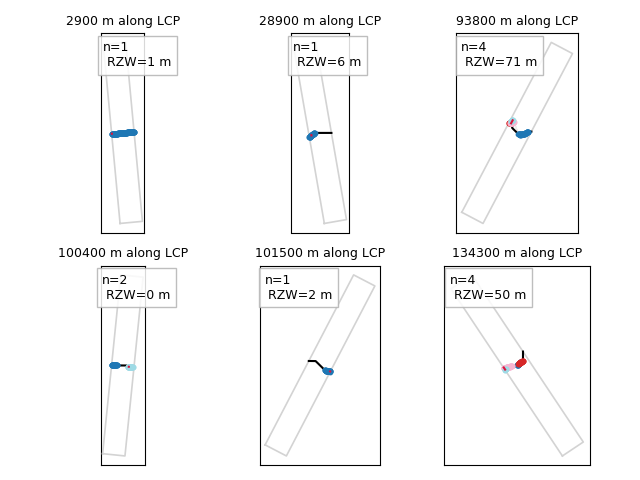

In [10]:
# plot some boxes to visualize the RZW measurements, randomly sampled n_test windows
n_tests = 6
utils.plot_rupture_zone_width_windows(lcp, rupture_map, roughness_n_strands_RZW_df, along_half, across_half, n=6, width_bin=width_bin, random_state=None)

### Visualization of metrics along LCP line

Visualize roughness and number of strands in map view and with magnitude plotted along strike

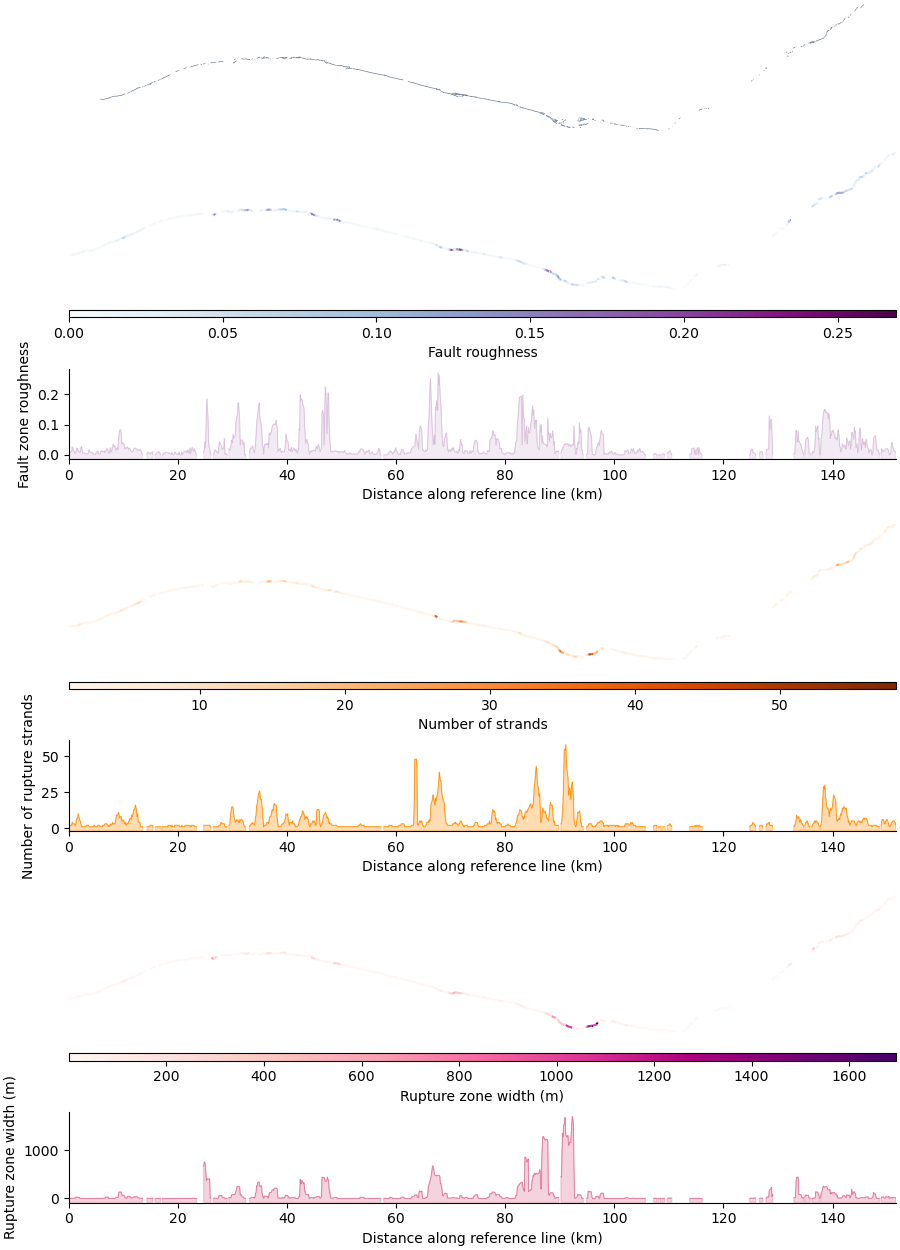

In [11]:
df = roughness_n_strands_RZW_df
x_km = df['distance along lcp line'].values / 1000.0
rough = df['roughness'].values
nstr = df['n_strands'].values.astype(float)
rzw  = df['rupture_zone_width'].values
mid = df[['x_coord_midpoint', 'y_coord_midpoint']].values

def colored_lcp(ax, cax, mid, vals, cmap, label, lognorm=False):
    segs = np.stack([mid[:-1], mid[1:]], axis=1)
    cvals = vals[:-1]
    if lognorm:
        pos = vals[np.isfinite(vals) & (vals > 0)]
        norm = LogNorm(pos.min(), pos.max())
    else:
        norm = Normalize(np.nanmin(vals), np.nanmax(vals))
    lc = LineCollection(segs, cmap=cmap, norm=norm)
    lc.set_array(cvals)
    lc.set_linewidth(1.5)
    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0)
    ax.set_aspect('equal')
    ax.axis('off')
    cb = ax.figure.colorbar(lc, cax=cax, orientation='horizontal')
    cb.set_label(label)

fig = plt.figure(figsize=(9, 12.5), constrained_layout=True)
gs = GridSpec(10, 2, figure=fig,
            height_ratios=[0.7, 0.9, 0.04, 0.5, 0.9, 0.04, 0.5, 0.9, 0.04, 0.5])

# 1 — rupture map (no frame)
ax1 = fig.add_subplot(gs[0, :])
rupture_map.plot(ax=ax1, color='slategray', lw=0.5)
ax1.margins(0); ax1.set_aspect('equal'); ax1.axis('off')

# 2 — LCP colored by roughness
ax2 = fig.add_subplot(gs[1, :])
cax2 = fig.add_subplot(gs[2, :])
colored_lcp(ax2, cax2, mid, rough, 'BuPu', 'Fault roughness')

# 3 — roughness along LCP
ax3 = fig.add_subplot(gs[3, :])
ax3.plot(x_km, rough,lw=0.5,color='thistle')
base = ax3.get_ylim()[0]
ax3.fill_between(x_km, rough, base, alpha=0.3,color='thistle')
ax3.set_ylim(bottom=base)
ax3.margins(x=0)
ax3.set_ylabel(f"Fault zone roughness")
ax3.set_xlabel("Distance along reference line (km)")

# 4 — LCP colored by number of strands
ax4 = fig.add_subplot(gs[4, :])
cax4 = fig.add_subplot(gs[5, :])
colored_lcp(ax4, cax4, mid, nstr, 'Oranges', 'Number of strands')

# 5 — number of strands along LCP
ax5 = fig.add_subplot(gs[6, :])
ax5.plot(x_km, nstr, lw=0.5,color='darkorange')
base = ax5.get_ylim()[0]
ax5.fill_between(x_km, nstr, base, alpha=0.3,color='darkorange')
ax5.set_ylim(bottom=base)
ax5.margins(x=0)
ax5.set_ylabel(f"Number of rupture strands")
ax5.set_xlabel("Distance along reference line (km)")

# 6 — LCP colored by rupture zone width
ax6 = fig.add_subplot(gs[7, :])
cax6 = fig.add_subplot(gs[8, :])
colored_lcp(ax6, cax6, mid, rzw, 'RdPu', 'Rupture zone width (m)')

# 7 — rupture zone width along LCP
ax7 = fig.add_subplot(gs[9, :])
ax7.plot(x_km, rzw, lw=0.5, color='palevioletred')
base = ax7.get_ylim()[0]
ax7.fill_between(x_km, rzw, base, alpha=0.3, color='palevioletred')
ax7.set_ylim(bottom=base)
ax7.margins(x=0)
ax7.set_ylabel(f"Rupture zone width (m)")
ax7.set_xlabel("Distance along reference line (km)")

for ax in (ax3, ax5, ax7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# plt.savefig('Figures/rupture_metrics_first_pass.pdf')

### Visualize and save metrics at sample locations

Add field sample locations and extract roughness and number of strands for each site. Save and export as csv.

Note: csv file with all field locations are then restricted to the ones for this project only

In [12]:
# read sites and transform coords to utm
field_samples = pd.read_csv('Field_Data/2025_Turkey_samples.csv')
field_samples = gpd.GeoDataFrame(
    field_samples,
    geometry=gpd.points_from_xy(field_samples.longitude, field_samples.latitude),
    crs="EPSG:4326",
).to_crs(epsg=32637)

# cut to samples for this project only 
site_map = {
    "A23-16":  1,
    "A23-26A": 2, "A23-26B": 2,
    "A23-24":  3,
    "A23-10A": 4, "A23-11":  4,
    "TK25-3":  5,
    "A23-5":   6,
    "A23-28A":  7,"A23-28AB":  7, "A23-28C":  7,
    "TK25-2":  8,
    "A24-2B":  9,
}

field_samples["Sample ID"] = field_samples["Sample ID"].str.strip()
field_samples = field_samples[field_samples["Sample ID"].isin(site_map)].copy()
field_samples["site"] = field_samples["Sample ID"].map(site_map)
field_samples = field_samples.sort_values(["site", "Sample ID"]).reset_index(drop=True)

field_samples["x_utm"] = field_samples.geometry.x
field_samples["y_utm"] = field_samples.geometry.y

# find position along ref line where each field sample falls
line = lcp.geometry.iloc[0]
field_samples["dist_along_lcp"] = field_samples.geometry.apply(line.project) # project field site onto its position on lcp line
field_samples.head()

,Sample ID,latitude,longitude,geometry,site,x_utm,y_utm,dist_along_lcp
0,A23-16,38.06508,36.96174,POINT (321195.349 4214997.202),1,321195.348701,4.214997e+06,44276.505480
1,A23-26A,38.05330,37.04028,POINT (328058.293 4213541.705),2,328058.293422,4.213542e+06,51614.638779
2,A23-26B,38.05330,37.04028,POINT (328058.293 4213541.705),2,328058.293422,4.213542e+06,51614.638779
3,A23-24,38.03255,37.15418,POINT (338006.775 4211034.483),3,338006.775086,4.211034e+06,61997.102758
4,A23-10A,38.02002,37.23339,POINT (344932.549 4209509.012),4,344932.549177,4.209509e+06,69548.212336


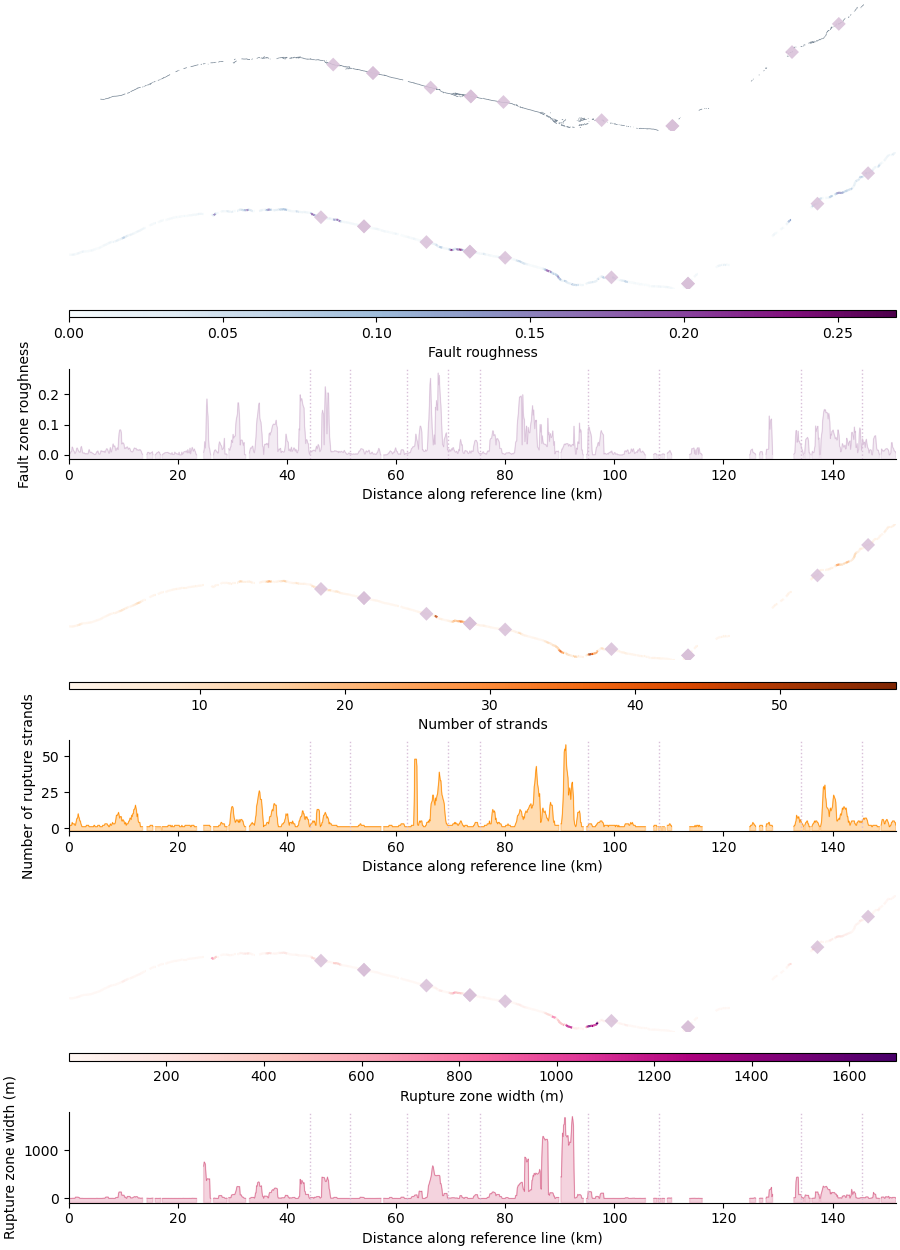

In [13]:
fig = plt.figure(figsize=(9, 12.5), constrained_layout=True)
gs = GridSpec(10, 2, figure=fig,
            height_ratios=[0.7, 0.9, 0.04, 0.5, 0.9, 0.04, 0.5, 0.9, 0.04, 0.5])

# 1 — rupture map (no frame)
ax1 = fig.add_subplot(gs[0, :])
rupture_map.plot(ax=ax1, color='slategray', lw=0.5)
ax1.margins(0); ax1.set_aspect('equal'); ax1.axis('off')

# 2 — LCP colored by roughness
ax2 = fig.add_subplot(gs[1, :])
cax2 = fig.add_subplot(gs[2, :])
colored_lcp(ax2, cax2, mid, rough, 'BuPu', 'Fault roughness')

# 3 — roughness along LCP
ax3 = fig.add_subplot(gs[3, :])
ax3.plot(x_km, rough,lw=0.5,color='thistle')
base = ax3.get_ylim()[0]
ax3.fill_between(x_km, rough, base, alpha=0.3,color='thistle')
ax3.set_ylim(bottom=base)
ax3.margins(x=0)
ax3.set_ylabel(f"Fault zone roughness")
ax3.set_xlabel("Distance along reference line (km)")

# 4 — LCP colored by number of strands
ax4 = fig.add_subplot(gs[4, :])
cax4 = fig.add_subplot(gs[5, :])
colored_lcp(ax4, cax4, mid, nstr, 'Oranges', 'Number of strands')

# 5 — number of strands along LCP
ax5 = fig.add_subplot(gs[6, :])
ax5.plot(x_km, nstr, lw=0.5,color='darkorange')
base = ax5.get_ylim()[0]
ax5.fill_between(x_km, nstr, base, alpha=0.3,color='darkorange')
ax5.set_ylim(bottom=base)
ax5.margins(x=0)
ax5.set_ylabel(f"Number of rupture strands")
ax5.set_xlabel("Distance along reference line (km)")

# 6 — LCP colored by rupture zone width
ax6 = fig.add_subplot(gs[7, :])
cax6 = fig.add_subplot(gs[8, :])
colored_lcp(ax6, cax6, mid, rzw, 'RdPu', 'Rupture zone width (m)')

# 7 — rupture zone width along LCP
ax7 = fig.add_subplot(gs[9, :])
ax7.plot(x_km, rzw, lw=0.5, color='palevioletred')
base = ax7.get_ylim()[0]
ax7.fill_between(x_km, rzw, base, alpha=0.3, color='palevioletred')
ax7.set_ylim(bottom=base)
ax7.margins(x=0)
ax7.set_ylabel(f"Rupture zone width (m)")
ax7.set_xlabel("Distance along reference line (km)")

for ax in (ax3, ax5, ax7):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# field samples: rhombs on the maps, vertical lines on the along-strike plots
sx = field_samples["x_utm"].values
sy = field_samples["y_utm"].values
s_along_km = field_samples["dist_along_lcp"].values / 1000.0

for ax in (ax1, ax2, ax4, ax6):
    ax.scatter(sx, sy, marker="D", s=50, facecolor="thistle",
            edgecolor="none", lw=0.8, alpha=0.85, zorder=6)

for ax in (ax3, ax5, ax7):
    for xv in np.unique(s_along_km):
        ax.axvline(xv, color="thistle", lw=1, ls=":", alpha=1, zorder=2)

plt.savefig('Figures/rupture_metrics_first_pass_w_fieldsites.pdf', dpi=300)

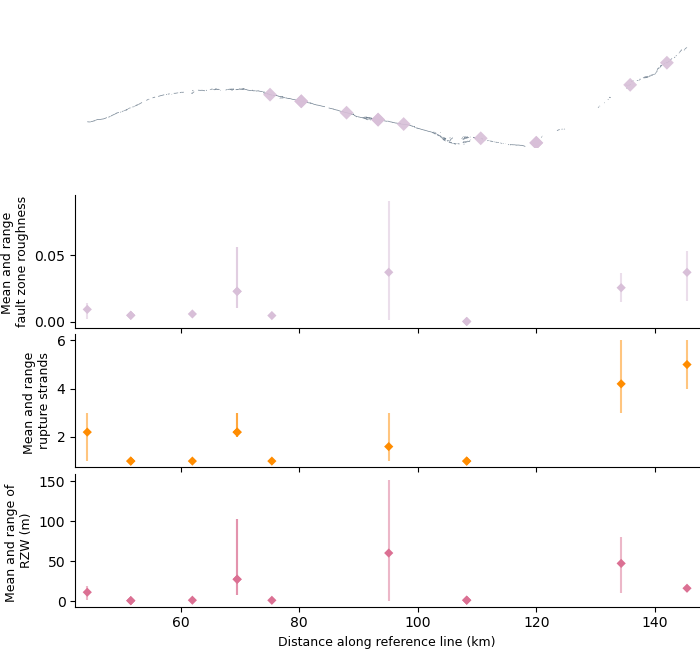

In [14]:
meas_dist = roughness_n_strands_RZW_df["distance along lcp line"].values
rough_arr = roughness_n_strands_RZW_df["roughness"].values
nstr_arr  = roughness_n_strands_RZW_df["n_strands"].values
rzw_arr   = roughness_n_strands_RZW_df["rupture_zone_width"].values

N = 250.0
avg_box = int(2 * N)
ordered = field_samples.sort_values("dist_along_lcp")
site_km   = ordered["dist_along_lcp"].values / 1000.0
site_dist = ordered["dist_along_lcp"].values

rough_lo, rough_hi, rough_mid = [], [], []
nstr_lo,  nstr_hi,  nstr_mid  = [], [], []
rzw_lo,   rzw_hi,   rzw_mid   = [], [], []
for d in site_dist:
    m = np.abs(meas_dist - d) <= N
    rv = rough_arr[m]; rv = rv[np.isfinite(rv)]
    nv = nstr_arr[m].astype(float); nv = nv[np.isfinite(nv)]
    wv = rzw_arr[m].astype(float); wv = wv[np.isfinite(wv)]
    rough_lo.append(rv.min() if rv.size else np.nan)  # dealing with empty boxes
    rough_hi.append(rv.max() if rv.size else np.nan)
    rough_mid.append(rv.mean() if rv.size else np.nan)
    nstr_lo.append(nv.min() if nv.size else np.nan)
    nstr_hi.append(nv.max() if nv.size else np.nan)
    nstr_mid.append(nv.mean() if nv.size else np.nan)
    rzw_lo.append(wv.min() if wv.size else np.nan)
    rzw_hi.append(wv.max() if wv.size else np.nan)
    rzw_mid.append(wv.mean() if wv.size else np.nan)

fig = plt.figure(figsize=(7, 6.5), constrained_layout=True)
fig.set_constrained_layout_pads(h_pad=0.01, hspace=0.01, w_pad=0.01, wspace=0.01)
gs = GridSpec(4, 1, figure=fig, height_ratios=[1.3, 0.9, 0.9, 0.9])

axm = fig.add_subplot(gs[0])
rupture_map.plot(ax=axm, color="slategray", lw=0.5, zorder=1)
axm.scatter(ordered["x_utm"], ordered["y_utm"], marker="D", s=50,
            facecolor="thistle", edgecolor="none", alpha=0.9, zorder=6)
# for _, r in ordered.iterrows():
#     axm.annotate(r["Sample ID"], (r["x_utm"], r["y_utm"]),
#                 xytext=(2, 2), textcoords="offset points",
#                 fontsize=5, ha="left", va="bottom")
axm.set_aspect("equal"); axm.margins(0.02); axm.axis("off")

# roughness, bar = range within +/- N m, diamond = mean
axa = fig.add_subplot(gs[1])
axa.vlines(site_km, rough_lo, rough_hi, color="thistle", lw=1.5, alpha=0.5)
axa.scatter(site_km, rough_mid, marker="D", s=22,
            facecolor="thistle", edgecolor="none", zorder=6)
axa.set_ylabel(f"Mean and range \nfault zone roughness", fontsize=9)
plt.setp(axa.get_xticklabels(), visible=False)

# strands, bar = range within +/- N m, diamond = mean
axb = fig.add_subplot(gs[2], sharex=axa)
axb.vlines(site_km, nstr_lo, nstr_hi, color="darkorange", lw=1.5, alpha=0.5)
axb.scatter(site_km, nstr_mid, marker="D", s=22,
            facecolor="darkorange", edgecolor="none", zorder=6)
axb.set_ylabel(f"Mean and range \nrupture strands", fontsize=9)
plt.setp(axb.get_xticklabels(), visible=False)

# rupture zone width, bar = range within +/- N m, diamond = mean
axc = fig.add_subplot(gs[3], sharex=axa)
axc.vlines(site_km, rzw_lo, rzw_hi, color="palevioletred", lw=1.5, alpha=0.5)
axc.scatter(site_km, rzw_mid, marker="D", s=22,
            facecolor="palevioletred", edgecolor="none", zorder=6)
axc.set_ylabel(f"Mean and range of \nRZW (m)", fontsize=9)
axc.set_xlabel("Distance along reference line (km)", fontsize=9)

for ax in (axa, axb, axc):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.margins(x=0.02)

plt.savefig('Figures/field_samples_n_strands_roughness_FZW.pdf', dpi=300, bbox_inches='tight')

In [15]:
# export mean + range for each field site
rzw_arr = roughness_n_strands_RZW_df["rupture_zone_width"].values

rows = []
for site, g in field_samples.groupby("site"):
    d = g["dist_along_lcp"].mean()
    m = np.abs(meas_dist - d) <= N
    rv = rough_arr[m]; rv = rv[np.isfinite(rv)]
    nv = nstr_arr[m].astype(float); nv = nv[np.isfinite(nv)]
    wv = rzw_arr[m].astype(float); wv = wv[np.isfinite(wv)]
    rows.append({
        "site": site,
        "sample_ids": ", ".join(g["Sample ID"]),
        "dist_along_lcp_m": d,
        "x_utm": g["x_utm"].mean(),
        "y_utm": g["y_utm"].mean(),
        "roughness_mean": rv.mean() if rv.size else np.nan,
        "roughness_min":  rv.min()  if rv.size else np.nan,
        "roughness_max":  rv.max()  if rv.size else np.nan,
        "n_strands_mean": nv.mean() if nv.size else np.nan,
        "n_strands_min":  nv.min()  if nv.size else np.nan,
        "n_strands_max":  nv.max()  if nv.size else np.nan,
        "rzw_mean": wv.mean() if wv.size else np.nan,
        "rzw_min":  wv.min()  if wv.size else np.nan,
        "rzw_max":  wv.max()  if wv.size else np.nan,
    })

site_summary = pd.DataFrame(rows).sort_values("site").reset_index(drop=True)
site_summary.to_csv("Field_Data/field_site_summary.csv", index=False)
site_summary

,site,sample_ids,dist_along_lcp_m,x_utm,y_utm,roughness_mean,roughness_min,roughness_max,n_strands_mean,n_strands_min,n_strands_max,rzw_mean,rzw_min,rzw_max
0,1,A23-16,44276.505480,321195.348701,4.214997e+06,0.009177,0.002210,0.014078,2.2,1.0,3.0,11.218848,0.910567,18.605606
1,2,"A23-26A, A23-26B",51614.638779,328058.293422,4.213542e+06,0.004708,0.003023,0.006420,1.0,1.0,1.0,0.667613,0.615409,0.758730
2,3,A23-24,61997.102758,338006.775086,4.211034e+06,0.005726,0.004881,0.007231,1.0,1.0,1.0,1.226548,0.920456,1.728053
3,4,"A23-10A, A23-11",69548.212336,344932.549177,4.209509e+06,0.022828,0.010079,0.056429,2.2,2.0,3.0,27.444085,8.216331,103.272746
4,5,TK25-3,75401.587727,350555.024646,4.208538e+06,0.004517,0.003154,0.005968,1.0,1.0,1.0,1.102360,0.692050,2.667900
5,6,A23-5,95106.565870,367487.877000,4.205411e+06,0.037244,0.001089,0.091276,1.6,1.0,3.0,60.283020,0.664428,151.693592
6,7,"A23-28A, A23-28C",108257.401875,379692.530638,4.204408e+06,0.000061,0.000056,0.000062,1.0,1.0,1.0,1.247226,1.233627,1.301624
7,8,TK25-2,134298.925888,400319.881135,4.217155e+06,0.025568,0.014605,0.037063,4.2,3.0,6.0,47.295692,10.697648,80.562230
8,9,A24-2B,145400.651926,408389.777438,4.222012e+06,0.037192,0.015373,0.053230,5.0,4.0,6.0,16.190272,15.679917,17.137020


In [16]:
along_halves = np.linspace(250, 2000, 10).round().astype(int)   # 10 window sizes along strike, 250 m -> 2 km

frames = []
for ah in along_halves:
    rns = utils.roughness_n_strands_along_lcp(lcp, rupture_map, ah, across_half, along_trace_step)
    rzw = utils.rupture_zone_width_along_lcp(lcp, rupture_map, ah, across_half, along_trace_step, width_bin=width_bin)
    rns["rupture_zone_width"] = rzw["rupture_zone_width"].values   # rows align (same windows)
    rns["along_half"] = ah
    frames.append(rns)

sweep_df = pd.concat(frames, ignore_index=True)
sweep_df.head()

,distance along lcp line,x_coord_midpoint,y_coord_midpoint,n_strands,roughness,rupture_zone_width,along_half
0,0.0,281039.666685,4.209040e+06,1.0,0.003127,0.645637,250
1,100.0,281138.921096,4.209030e+06,1.0,0.003254,0.724545,250
2,200.0,281238.133735,4.209020e+06,2.0,0.004512,0.788605,250
3,300.0,281336.775081,4.209007e+06,2.0,0.007300,0.906648,250
4,400.0,281436.431657,4.209002e+06,2.0,0.011372,1.388610,250


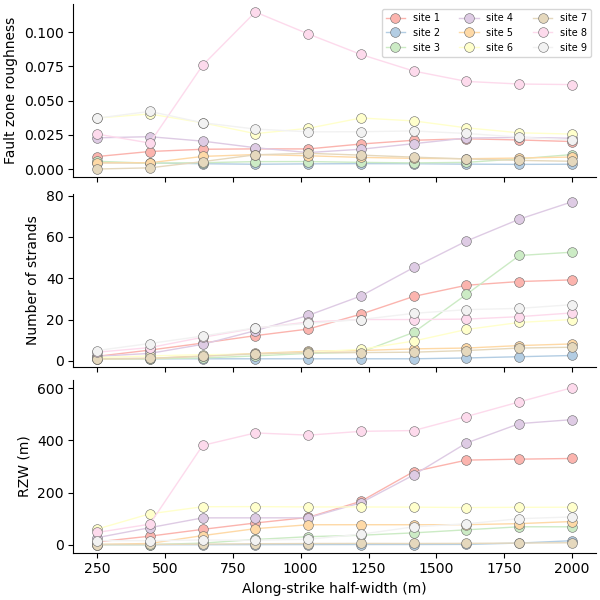

In [17]:
metrics = [("roughness", "Fault zone roughness"),
        ("n_strands", "Number of strands"),
        ("rupture_zone_width", "RZW (m)")]

# one row per site (collapse co-located samples), ordered along the reference line
site_tbl = (field_samples.groupby("site", as_index=False)
            .agg(dist=("dist_along_lcp", "mean"))
            .sort_values("dist").reset_index(drop=True))
site_dist = site_tbl["dist"].values

# for each along_half, average each metric over the windows within +/- N of each site
vals = {col: np.full((len(site_tbl), len(along_halves)), np.nan) for col, _ in metrics}
for j, ah in enumerate(along_halves):
    sub = sweep_df[sweep_df["along_half"] == ah]
    md = sub["distance along lcp line"].values
    arrs = {col: sub[col].values.astype(float) for col, _ in metrics}
    for i, d in enumerate(site_dist):
        m = np.abs(md - d) <= N
        for col, _ in metrics:
            v = arrs[col][m]
            v = v[np.isfinite(v)]
            if v.size:
                vals[col][i, j] = v.mean()

cmap = plt.get_cmap("Pastel1", len(site_tbl))
colors = {s: cmap(i) for i, s in enumerate(site_tbl["site"].values)}

fig, axes = plt.subplots(len(metrics), 1, figsize=(6, 6), sharex=True, constrained_layout=True)
for ax, (col, label) in zip(axes, metrics):
    for i, s in enumerate(site_tbl["site"].values):
        ax.plot(along_halves, vals[col][i], "-o", ms=7, lw=1, markeredgecolor='dimgray',
                markeredgewidth=0.4, color=colors[s], label=f"site {s}")
    ax.set_ylabel(label)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[-1].set_xlabel("Along-strike half-width (m)")
axes[0].legend(ncol=3, fontsize=7, loc="best")
plt.savefig("Figures/along_strike_window_sensitivity.pdf", dpi=300, bbox_inches='tight')

### Summary table of all parameter choices

In [18]:
params = pd.DataFrame([
    ("CRS (EPSG)",              32637,                "UTM 37N",  "projection for all geometry"),
    ("resample_step",          resample_step,         "m",        "rupture vertex spacing"),
    ("res",                     res,                  "m",        "LCP cost-grid resolution"),
    ("smooth_tol",              smooth_tol,           "m",        "PAEK-like LCP smoothing length"),
    ("along_half",              along_half,           "m",        "window half-length along strike"),
    ("across_half",             across_half,          "m",        "window half-width across strike"),
    ("along_trace_step",        along_trace_step,     "m",        "step between windows along LCP"),
    ("width_bin",               width_bin,            "m",        "RZW along-strike bin size"),
    ("N",                       N,                    "m",        "+/- averaging radius around each site"),
    ("along_halves (sweep)",    f"{along_halves.min()}-{along_halves.max()} ({len(along_halves)})", "m", "along_half values in sensitivity sweep"),
], columns=["parameter", "value", "unit", "description"])

params

,parameter,value,unit,description
0,CRS (EPSG),32637,UTM 37N,projection for all geometry
1,resample_step,5.0,m,rupture vertex spacing
2,res,1.5,m,LCP cost-grid resolution
3,smooth_tol,3.0,m,PAEK-like LCP smoothing length
4,along_half,250,m,window half-length along strike
5,across_half,2000,m,window half-width across strike
6,along_trace_step,100,m,step between windows along LCP
7,width_bin,10.0,m,RZW along-strike bin size
8,N,250.0,m,+/- averaging radius around each site
9,along_halves (sweep),250-2000 (10),m,along_half values in sensitivity sweep


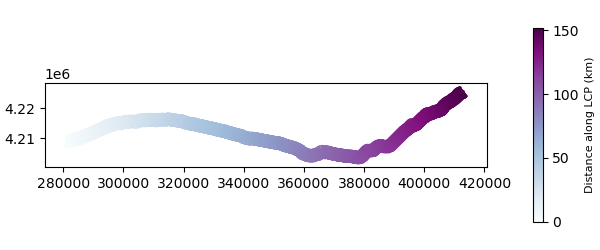

In [19]:
# checking that code is stepping along LCP line in order + window viz
line = lcp.geometry.iloc[0]
L = line.length
dists = np.arange(0.0, L + along_trace_step, along_trace_step)
k = 1                      # option to only show every kth box
d_sel = dists[::k]

cmap = plt.get_cmap("BuPu")
norm = Normalize(d_sel.min() / 1000.0, d_sel.max() / 1000.0)

fig, axt = plt.subplots(1, 1, figsize=(6, 2.5), constrained_layout=True)
rupture_map.plot(ax=axt, color="slategray", lw=0.5, zorder=1)
lcp.plot(ax=axt, color="k", lw=0.8, zorder=2)

# oriented windows in ascending order along the LCP, colored by distance
centers = []
for d in d_sel:
    c0, along_dir, perp_dir, window = utils.oriented_window(line, d, L, along_half, across_half)
    centers.append(c0)
    px, py = window.exterior.xy
    axt.plot(px, py, color=cmap(norm(d / 1000.0)), lw=0.8, zorder=3)
centers = np.array(centers)

axt.scatter(centers[:, 0], centers[:, 1], s=3, c=d_sel / 1000.0,
            cmap=cmap, norm=norm, zorder=4)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cb = fig.colorbar(sm, ax=axt, orientation="vertical", shrink=0.8)
cb.set_label("Distance along LCP (km)", fontsize=8)